# Comparaison of samples

Apply to output files from summary_celltypes_IHOPE.py in CSV format.

In [34]:
import sys
from pathlib import Path
#TODO try to remove this somehow
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

In [35]:
import importlib
import scripts.comparison as comparison

importlib.reload(comparison)

from scripts.comparison import (
    load_celltype_summaries,
    pivot_for_heatmap,
    plot_celltype_heatmap,
    print_numeric_summary,
    pivot_for_tissue_heatmap,
    plot_celltype_heatmap,
    plot_celltype_clustermap
)


Define file names and sample names. Use the output from cell 1 to complete cell 2.

In [36]:
# Make a "fill the gap" template
summaries_dir = Path("../results/reports/NEW")
files = sorted(summaries_dir.glob("celltype_summary_*.csv"))

print("name_map = {")
for f in files:
    print(f'    "{f.name}": "",')
print("}")

name_map = {
    "celltype_summary_IHOPE14_MedLN_BottomLeft_filtered_arcsinh_cf5.0_IHOPE_NEW_summary.csv": "",
    "celltype_summary_IHOPE14_MedLN_BottomRight_filtered_arcsinh_cf5.0_IHOPE_NEW_summary.csv": "",
    "celltype_summary_IHOPE14_MedLN_TopRight_filtered_arcsinh_cf5.0_IHOPE_NEW_summary.csv": "",
    "celltype_summary_IHOPE14_mesLN_filtered_arcsinh_cf5.0_IHOPE_NEW_summary.csv": "",
    "celltype_summary_IHOPE20_LN_filtered_arcsinh_cf5.0_IHOPE_NEW_summary.csv": "",
    "celltype_summary_IHOPE20_Spleen_filtered_arcsinh_cf5.0_IHOPE_NEW_summary.csv": "",
    "celltype_summary_IHOPE26_LN_filtered_arcsinh_cf5.0_IHOPE_NEW_summary.csv": "",
    "celltype_summary_IHOPE26_Spleen_filtered_arcsinh_cf5.0_IHOPE_NEW_summary.csv": "",
    "celltype_summary_IHOPE27_LN_filtered_arcsinh_cf5.0_IHOPE_NEW_summary.csv": "",
    "celltype_summary_IHOPE27_Spleen_filtered_arcsinh_cf5.0_IHOPE_NEW_summary.csv": "",
    "celltype_summary_IHOPE39_LN_filtered_arcsinh_cf5.0_IHOPE_NEW_summary.csv": "",
    "ce

In [4]:
# Can of course change later to make the plot look prettier
name_map = {
    "celltype_summary_IHOPE14_MedLN_BottomLeft_filtered_arcsinh_cf5.0_IHOPE_NEW_summary.csv": "IHOPE14_MedLN_BottomLeft",
    "celltype_summary_IHOPE14_MedLN_BottomRight_filtered_arcsinh_cf5.0_IHOPE_NEW_summary.csv": "IHOPE14_MedLN_BottomRight",
    "celltype_summary_IHOPE14_MedLN_TopRight_filtered_arcsinh_cf5.0_IHOPE_NEW_summary.csv": "IHOPE14_MedLN_TopRight",
    "celltype_summary_IHOPE14_mesLN_filtered_arcsinh_cf5.0_IHOPE_NEW_summary.csv": "IHOPE14_mesLN",
    "celltype_summary_IHOPE20_LN_filtered_arcsinh_cf5.0_IHOPE_NEW_summary.csv": "IHOPE20_LN",
    "celltype_summary_IHOPE20_Spleen_filtered_arcsinh_cf5.0_IHOPE_NEW_summary.csv": "IHOPE20_Spleen",
    "celltype_summary_IHOPE26_LN_filtered_arcsinh_cf5.0_IHOPE_NEW_summary.csv": "IHOPE26_LN",
    "celltype_summary_IHOPE26_Spleen_filtered_arcsinh_cf5.0_IHOPE_NEW_summary.csv": "IHOPE26_Spleen",
    "celltype_summary_IHOPE27_LN_filtered_arcsinh_cf5.0_IHOPE_NEW_summary.csv": "IHOPE27_LN",
    "celltype_summary_IHOPE27_Spleen_filtered_arcsinh_cf5.0_IHOPE_NEW_summary.csv": "IHOPE27_Spleen",
    "celltype_summary_IHOPE39_LN_filtered_arcsinh_cf5.0_IHOPE_NEW_summary.csv": "IHOPE39_LN",
    "celltype_summary_IHOPE39_MesLN_1_filtered_arcsinh_cf5.0_IHOPE_NEW_summary.csv": "IHOPE39_MesLN_1",
    "celltype_summary_IHOPE39_Spleen_filtered_arcsinh_cf5.0_IHOPE_NEW_summary.csv": "IHOPE39_Spleen",
}

In [5]:
file_map = {
    sample: summaries_dir / fname
    for fname, sample in name_map.items()
}

In [6]:
# Sanity check
for sample, path in file_map.items():
    print(sample, ": ", path.name)

IHOPE14_MedLN_BottomLeft :  celltype_summary_IHOPE14_MedLN_BottomLeft_filtered_arcsinh_cf5.0_IHOPE_NEW_summary.csv
IHOPE14_MedLN_BottomRight :  celltype_summary_IHOPE14_MedLN_BottomRight_filtered_arcsinh_cf5.0_IHOPE_NEW_summary.csv
IHOPE14_MedLN_TopRight :  celltype_summary_IHOPE14_MedLN_TopRight_filtered_arcsinh_cf5.0_IHOPE_NEW_summary.csv
IHOPE14_mesLN :  celltype_summary_IHOPE14_mesLN_filtered_arcsinh_cf5.0_IHOPE_NEW_summary.csv
IHOPE20_LN :  celltype_summary_IHOPE20_LN_filtered_arcsinh_cf5.0_IHOPE_NEW_summary.csv
IHOPE20_Spleen :  celltype_summary_IHOPE20_Spleen_filtered_arcsinh_cf5.0_IHOPE_NEW_summary.csv
IHOPE26_LN :  celltype_summary_IHOPE26_LN_filtered_arcsinh_cf5.0_IHOPE_NEW_summary.csv
IHOPE26_Spleen :  celltype_summary_IHOPE26_Spleen_filtered_arcsinh_cf5.0_IHOPE_NEW_summary.csv
IHOPE27_LN :  celltype_summary_IHOPE27_LN_filtered_arcsinh_cf5.0_IHOPE_NEW_summary.csv
IHOPE27_Spleen :  celltype_summary_IHOPE27_Spleen_filtered_arcsinh_cf5.0_IHOPE_NEW_summary.csv
IHOPE39_LN :  cell

Load data frame

In [7]:
df = load_celltype_summaries(file_map=file_map)

matrix = pivot_for_heatmap(df)

Plot cell type heatmap

In [ ]:
# Log scale to improve coloring for low-abundant cell types:
plot_matrix = np.log10(matrix + 0.1)

In [ ]:
plot_celltype_heatmap(
    plot_matrix,
    scale = "log",
    colorbar_legend="Log percentage +0.1"
)

In [ ]:
# Raw percentages:
plot_celltype_heatmap(
    matrix,
    scale = "linear",
    colorbar_legend="Percentage"
)

Clustered:

In [ ]:
import importlib
import scripts.comparison as comparison

importlib.reload(comparison)

from scripts.comparison import (
    load_celltype_summaries,
    pivot_for_heatmap,
    plot_celltype_heatmap,
    print_numeric_summary,
    pivot_for_tissue_heatmap,
    plot_celltype_heatmap,
    plot_celltype_clustermap
)


In [ ]:
# Both axes

plot_celltype_clustermap(
    matrix,
    colorbar_legend="Percentage",
    scale="log"
)

In [ ]:
# Only cluster samples

plot_celltype_clustermap(
    matrix,
    colorbar_legend="Percentage",
    scale="log",
    cluster_rows=False,
    cluster_cols=True
)

In [ ]:
# With correlation metric instead of Euclidean

plot_celltype_clustermap(
    matrix,
    scale="log",
    cluster_rows=False,
    cluster_cols=True,
    metric="correlation"
)

Tissue type summary

In [9]:
tissue_map = {
    "IHOPE14_MedLN_BottomLeft": "MedLN",
    "IHOPE14_MedLN_BottomRight": "MedLN",
    "IHOPE14_MedLN_TopRight": "MedLN",
    "IHOPE14_mesLN": "MesLN",
    "IHOPE20_LN": "MedLN",
    "IHOPE20_Spleen": "Spleen",
    "IHOPE26_LN": "MedLN",
    "IHOPE26_Spleen": "Spleen",
    "IHOPE27_LN": "MedLN",
    "IHOPE27_Spleen": "Spleen",
    "IHOPE39_LN": "MedLN",
    "IHOPE39_MesLN_1": "MesLN",
    "IHOPE39_Spleen": "Spleen",
}

In [10]:
df = load_celltype_summaries(file_map=file_map)

df["tissue"] = df["sample"].map(tissue_map)

Using mean  (avoid dominance of large samples):

In [11]:
df_tissue = (
    df.groupby(["tissue", "level", "cell_type"], as_index=False)
      .agg(pct_total=("pct_total", "mean"))
)

In [13]:
import numpy as np
matrix_tissue = pivot_for_tissue_heatmap(df_tissue)

plot_matrix = np.log10(matrix_tissue + 0.1)

For log transformed percentages:

In [ ]:
plot_celltype_heatmap(
    plot_matrix,
    colorbar_legend="Percentage (log + 0.1)",
    scale="log"
)

Raw percentages:

In [ ]:
plot_celltype_heatmap(
    matrix_tissue,
    colorbar_legend="Percentage",
    scale="linear"
)

## Stacked barplot

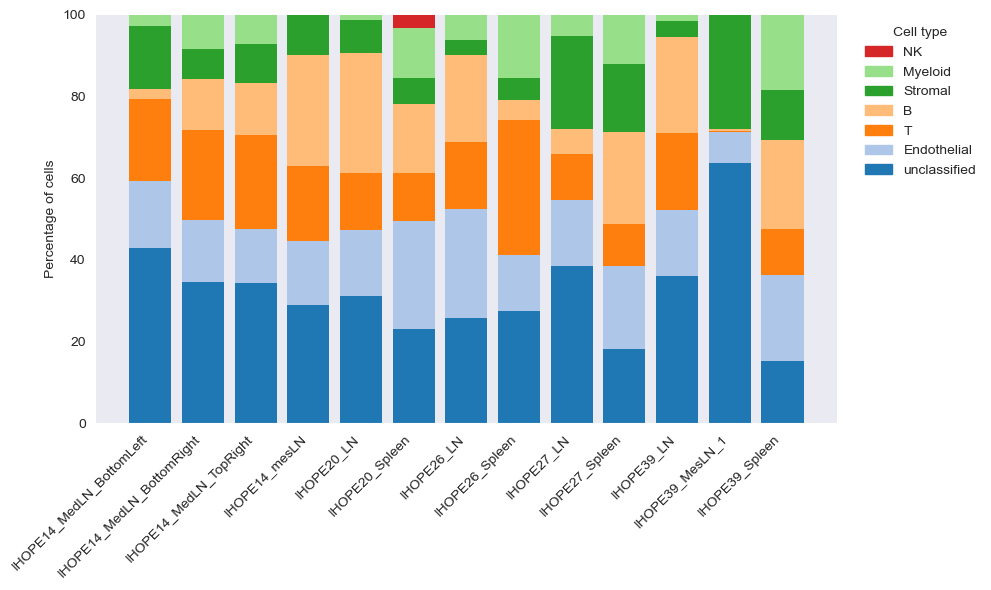

TypeError: plot_celltype_stacked_barplot() got an unexpected keyword argument 'groupby'

In [14]:
importlib.reload(comparison)
from scripts.comparison import plot_celltype_stacked_barplot

palette = plot_celltype_stacked_barplot(df, levels=["type"])

plot_celltype_stacked_barplot(
    df,
    levels=["type"],
    groupby="tissue",
    palette=palette
)

In [ ]:
importlib.reload(comparison)
from scripts.comparison import plot_celltype_stacked_barplot

palette = plot_celltype_stacked_barplot(
    df,
    levels=["subtype"],
    x="sample",
    title="Cell type composition per sample",
    ylim = (0, 80)
)

In [ ]:
importlib.reload(comparison)
from scripts.comparison import plot_celltype_stacked_barplot

plot_celltype_stacked_barplot(
    df_tissue,
    levels=["subtype"], #"type",
    x="tissue",
    palette=palette,  # reuse colors
    ylim = (0, 75)
)

In [26]:
import anndata as ad
import pandas as pd
import numpy as np

adata = ad.read_h5ad("../data/processed/anndata/NEW/IHOPE26_Spleen_celltypes_follicledomains.h5ad")
obs = adata.obs

# isolate layers
type_cols = [c for c in obs.columns if c.startswith("type_")]
int_cols  = [c for c in obs.columns if c.startswith("intermediate_")]
sub_cols  = [c for c in obs.columns if c.startswith("subtype_")]

def check_exclusivity(cols, name):
    mat = obs[cols].astype(int)

    row_sum = mat.sum(axis=1)

    print(f"\n=== {name} ===")
    print("n columns:", len(cols))
    print("cells:", len(obs))
    print("mean overlap:", row_sum.mean())
    print("max overlap:", row_sum.max())
    print("% cells with >1 assignment:", (row_sum > 1).mean())
    print("% unassigned (sum==0):", (row_sum == 0).mean())

check_exclusivity(type_cols, "TYPE")
check_exclusivity(int_cols, "INTERMEDIATE")
check_exclusivity(sub_cols, "SUBTYPE")


=== TYPE ===
n columns: 7
cells: 238378
mean overlap: 1.037641896483736
max overlap: 2
% cells with >1 assignment: 0.037641896483735914
% unassigned (sum==0): 0.0

=== INTERMEDIATE ===
n columns: 6
cells: 238378
mean overlap: 0.46215674265242596
max overlap: 2
% cells with >1 assignment: 0.1325332035674433
% unassigned (sum==0): 0.6703764609150173

=== SUBTYPE ===
n columns: 27
cells: 238378
mean overlap: 0.9096351173346534
max overlap: 5
% cells with >1 assignment: 0.16857260317646763
% unassigned (sum==0): 0.34395372056146123


In [33]:
import itertools

type_cols = [c for c in adata.obs.columns if c.startswith("type_")]

overlaps = []

for a, b in itertools.combinations(type_cols, 2):
    n = ((adata.obs[a]) & (adata.obs[b])).sum()
    if n > 0:
        overlaps.append((a, b, n))

sorted(overlaps, key=lambda x: -x[2])

[('type_NK', 'type_Myeloid', 4645),
 ('type_Stromal', 'type_Endothelial', 3885),
 ('type_B', 'type_NK', 443)]